In [15]:
# 학습
  # 지도학습
    # 문제 + 답
    # 회귀 : 연속적인 값을 예측
    # 분류 : 이산(범주) 값을 예측
    
  # 비지도학습
    # 문제 => 군집화
    # 군집화
    # 차원축소(PCA)
      # => 독립 변수들의 개수를 줄임
      # => 시각화, 속도, 노이즈 제거
    # 연관규칙학습
    
  # 강화학습
    # 보상 + 벌 => 학습
    # 게임같은 구조


## 차원 축소
* 독립변수의 개수를 2개로 줄임
### 왜?
* 속도 향상
* 노이즈 제거
* 시각화(독립변수가 2개면 2차원 그래프, 3개 => 3차원 그래프, 4개 => 못함) 

In [16]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt

# 데이터 생성
dataset = load_breast_cancer()


In [17]:
# 독립, 종속 분리(원래는 비지도이기 때문에 할 필요가 없음)
X, y = dataset.data, dataset.target
X


array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [18]:
# 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
from sklearn.decomposition import PCA
# n_components : 독립변수를 몇개로 줄일건지
model = PCA(n_components=2)
X_pca = model.fit_transform(X_scaled)
X_pca

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]], shape=(569, 2))

In [20]:
# 시각화 사전 작업
import pandas as pd
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y
print(pca_df.head())

        PC1        PC2  target
0  9.192837   1.948583       0
1  2.387802  -3.768172       0
2  5.733896  -1.075174       0
3  7.122953  10.275589       0
4  3.935302  -1.948072       0


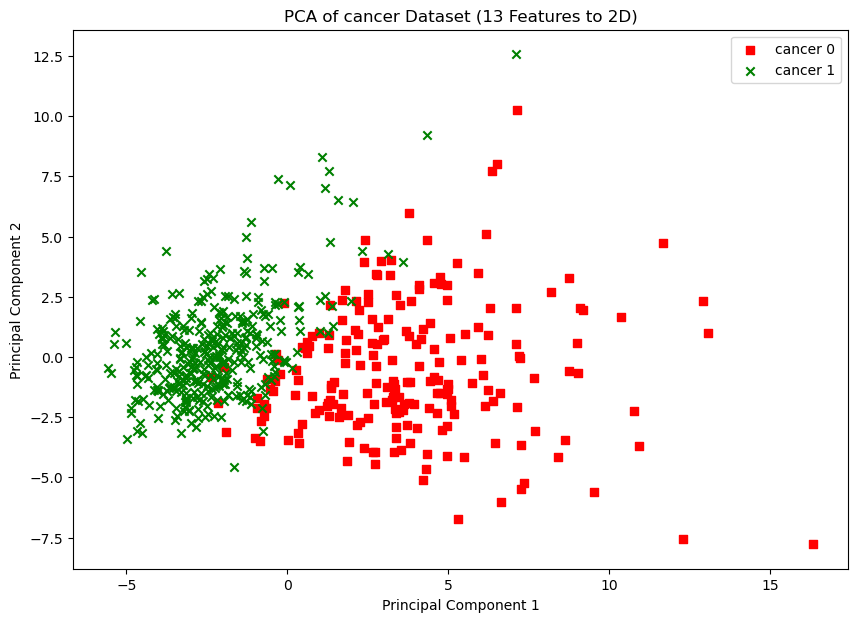

주성분 1 설명력: 0.44
주성분 2 설명력: 0.19
총 합계: 0.63


In [21]:
plt.figure(figsize=(10, 7))
colors = ['r', 'g']
markers = ['s', 'x']

for l, c, m in zip(range(2), colors, markers):
    plt.scatter(X_pca[y == l, 0], X_pca[y == l, 1], 
                c=c, label=f'cancer {l}', marker=m,)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.title('PCA of cancer Dataset (13 Features to 2D)')
plt.show()

# 각 주성분이 전체 분산의 몇 %를 설명하는지 출력
print(f"주성분 1 설명력: {model.explained_variance_ratio_[0]:.2f}")
print(f"주성분 2 설명력: {model.explained_variance_ratio_[1]:.2f}")
print(f"총 합계: {sum(model.explained_variance_ratio_):.2f}")